# 2802394525 - Tokesi Lukynawa

# Link Video

https://drive.google.com/drive/folders/1isgqm2QHeW9tcWtTWj8Q4SZW2cMjA9Ot?usp=sharing

Anda adalah seorang data scientist di sebuah institusi keuangan. Anda mendapati sebuah problem yang 
terjadi di institusi, dimana anda perlu menilai performa kredit setiap nasabah dengan menggunakan 
pendekatan data science. 

# Dataset (A) Ganjil


- **Unnamed: 0**: Kolom indeks yang dihasilkan secara otomatis oleh sistem sebagai penomoran setiap baris data.
- **ID**: Identitas unik yang digunakan untuk membedakan setiap catatan transaksi pelanggan.
- **Customer_ID**: Kode unik yang merepresentasikan masing-masing pelanggan.
- **Month**: Menunjukkan bulan saat data pelanggan dicatat.
- **Name**: Nama lengkap pelanggan.
- **Age**: Usia pelanggan yang dinyatakan dalam satuan tahun.
- **SSN**: Nomor identitas pelanggan berupa *Social Security Number (SSN)*.
- **Occupation**: Jenis pekerjaan atau profesi yang dimiliki pelanggan.
- **Annual_Income**: Total pendapatan pelanggan selama satu tahun.
- **Monthly_Inhand_Salary**: Gaji bersih yang diterima pelanggan setiap bulan setelah potongan.
- **Num_Bank_Accounts**: Jumlah rekening bank yang dimiliki pelanggan.
- **Num_Credit_Card**: Total kartu kredit yang dimiliki pelanggan.
- **Interest_Rate**: Besaran suku bunga yang dikenakan pada fasilitas kredit pelanggan.
- **Num_of_Loan**: Jumlah pinjaman yang dimiliki pelanggan.
- **Type_of_Loan**: Kategori atau jenis pinjaman yang dimiliki pelanggan.
- **Delay_from_due_date**: Jumlah hari keterlambatan pembayaran setelah melewati tanggal jatuh tempo.
- **Num_of_Delayed_Payment**: Total kejadian keterlambatan pembayaran yang pernah dilakukan pelanggan.
- **Changed_Credit_Limit**: Nilai perubahan yang terjadi pada batas maksimum kredit pelanggan.
- **Num_Credit_Inquiries**: Jumlah permintaan pengecekan riwayat kredit pelanggan.
- **Credit_Mix**: Komposisi atau kombinasi jenis kredit yang dimiliki pelanggan.
- **Outstanding_Debt**: Total utang yang masih menjadi kewajiban pelanggan.
- **Credit_Utilization_Ratio**: Persentase penggunaan limit kredit dibandingkan dengan total limit yang tersedia.
- **Credit_History_Age**: Lama riwayat kredit yang dimiliki pelanggan.
- **Payment_of_Min_Amount**: Menunjukkan apakah pelanggan hanya membayar sejumlah pembayaran minimum yang diwajibkan.
- **Total_EMI_per_month**: Total cicilan bulanan (*Equated Monthly Installment/EMI*) yang harus dibayarkan pelanggan.
- **Amount_invested_monthly**: Besarnya dana yang diinvestasikan pelanggan setiap bulan.
- **Payment_Behaviour**: Pola atau kebiasaan pelanggan dalam melakukan pembayaran.
- **Monthly_Balance**: Saldo akhir pelanggan pada setiap akhir bulan.
- **Credit_Score**: Kategori kualitas skor kredit pelanggan (**Poor**, **Standard**, atau **Good**). Variabel ini umumnya digunakan sebagai label atau target dalam proses klasifikasi.

## Target

- **Credit_Score**: Variabel target yang menunjukkan tingkat kualitas skor kredit pelanggan dengan kategori **Good**, **Standard**, dan **Poor**.

# Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (RobustScaler,OneHotEncoder,OrdinalEncoder,)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. EDA

### Read Data & Drop some Features

In [87]:
df = pd.read_csv("data_A.csv")
df.head(10)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor
5,5,0x241ce,CUS_0x5e18,January,Kuehnenn,49,287-80-7372,Entrepreneur,177723.8,15038.316667,...,_,1292.23,43.418096,29 Years and 11 Months,No,338.789953,221.9214457492741,High_spent_Large_value_payments,1183.1202677169836,Good
6,6,0x84e0,CUS_0x2e1d,March,Nanette Byrness,18,408-57-4420,Accountant,53251.36,4636.613333,...,Standard,861.67,26.007241,27 Years and 0 Months,NM,128.209844,181.32851493815124,Low_spent_Large_value_payments,424.1229741653374,Standard
7,7,0xc7a3,CUS_0xb4c5,June,Michaelj,51,873-29-1123,Journalist,61358.82,4923.235000,...,Standard,537.91,35.418729,25 Years and 2 Months,No,0.000000,161.55547025142175,Low_spent_Large_value_payments,600.7680297485782,Standard
8,8,0x23a68,CUS_0xb4fd,March,Chris Reesej,27,400-77-1931,_______,37070.0,2939.166667,...,Good,387.26,34.857314,27 Years and 10 Months,No,103.092665,173.65585522573414,Low_spent_Small_value_payments,307.1681466694969,Good
9,9,0x227d,CUS_0x6b44,April,Dan Levined,39_,453-58-1018,Developer,20742.46,1801.538333,...,_,1319.87,35.607534,16 Years and 5 Months,Yes,60.066113,NaN,!@9#%8,316.0208644912305,Standard


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [89]:
df = df.drop(columns=["Unnamed: 0","ID", "Customer_ID","SSN","Name","Month","Occupation"])

Beberapa `variable` yang tidak diperlukan untuk prediksi performa kredit akan saya drop karena hanya bersifat identifier & dapat menyebabkan overfitting ketika modelling

### Pembersihan dan Konversi beberapa Data Numerik

In [ ]:
def clean_numeric_column(series):
	return (
		series.astype(str) 	# Mengubah data menjadi string
			.str.replace(r'[^0-9.-]', '', regex=True) # Menghapus karakter selain angka, titik, dan minus (-)
			.replace('', np.nan) #Isi dengan NaN jika kosong
			.astype(float) #Kembalikan Ke Float
	)

# Mengganti string kosong hasil pembersihan menjadi NaN
cols_to_clean = ['Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment','Changed_Credit_Limit','Amount_invested_monthly','Outstanding_Debt','Monthly_Balance']

for col in cols_to_clean:
    df[col] = clean_numeric_column(df[col])

df[cols_to_clean].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      25000 non-null  float64
 1   Annual_Income            25000 non-null  float64
 2   Num_of_Loan              25000 non-null  float64
 3   Num_of_Delayed_Payment   23267 non-null  float64
 4   Changed_Credit_Limit     24482 non-null  float64
 5   Amount_invested_monthly  23836 non-null  float64
 6   Outstanding_Debt         25000 non-null  float64
 7   Monthly_Balance          24711 non-null  float64
dtypes: float64(8)
memory usage: 1.5 MB


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       25000 non-null  float64
 1   Annual_Income             25000 non-null  float64
 2   Monthly_Inhand_Salary     21417 non-null  float64
 3   Num_Bank_Accounts         25000 non-null  int64  
 4   Num_Credit_Card           25000 non-null  int64  
 5   Interest_Rate             25000 non-null  int64  
 6   Num_of_Loan               25000 non-null  float64
 7   Type_of_Loan              22172 non-null  object 
 8   Delay_from_due_date       25000 non-null  int64  
 9   Num_of_Delayed_Payment    23267 non-null  float64
 10  Changed_Credit_Limit      24482 non-null  float64
 11  Num_Credit_Inquiries      24494 non-null  float64
 12  Credit_Mix                25000 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

### Missing Value Check

In [92]:
df.isnull().sum()

Age                            0
Annual_Income                  0
Monthly_Inhand_Salary       3583
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2828
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit         518
Num_Credit_Inquiries         506
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2249
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1164
Payment_Behaviour              0
Monthly_Balance              289
Credit_Score                   0
dtype: int64

Disini proses handling missing value akan dilakukan impute data setelah train test split untuk mencegah data leakage

### Categorical Check

#### Check values setiap kolom Categorical

In [93]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"COMPOSITION OF COLUMN '{col}':\n")
    print(df[col].value_counts(), end="\n\n\n\n")

COMPOSITION OF COLUMN 'Type_of_Loan':

Type_of_Loan
Not Specified                                                                                                   355
Credit-Builder Loan                                                                                             319
Debt Consolidation Loan                                                                                         318
Personal Loan                                                                                                   317
Mortgage Loan                                                                                                   295
                                                                                                               ... 
Not Specified, Student Loan, Debt Consolidation Loan, and Student Loan                                            1
Personal Loan, Mortgage Loan, Mortgage Loan, Personal Loan, Student Loan, Credit-Builder Loan, and Auto Loan      1
Mortgage Loan, Auto 

#### Handling  `Credit_Mix`,`Payment_of_Min_Amount`,`Payment_Behaviour`

In [94]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_','Unknown')
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM','Unknown')
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8','Unknown')

#### Handling `Type_of_Loan`

**Type_of_Loan** merupakan multi-valued categorical variable dengan jumlah nilai unik yang sangat banyak akibat kombinasi dan urutan jenis pinjaman yang beragam dalam satu entri. Oleh karena itu, kolom ini ditransformasikan dengan membuat fitur numerik baru, yaitu **Num_Type_of_Loan**, yang merepresentasikan jumlah jenis pinjaman yang dimiliki pelanggan. Dan kolom **Type_of_Loan** di awal akan di drop agar mempermudah proses analisis selanjutnya.

In [95]:
df['Type_of_Loan'] = df['Type_of_Loan'].replace('Not Specified', np.nan)

df['Num_Type_of_Loan'] = df['Type_of_Loan'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

df = df.drop(columns=['Type_of_Loan'])

#### Handling `Credit_History_Age`

Kolom **Credit_History_Age** merupakan kolom yang memiliki fitur dengan isi durasi yang disimpan dalam format teks berupa kombinasi tahun dan bulan. Karena variabel ini aslinya bersifat numerik dan kontinu dengan nama kolom **Credit_History_Age_Months**, kolom tersebut ditransformasikan menjadi fitur numerik dengan menghitung total usia riwayat kredit dalam satuan bulan. Setelah proses transformasi dilakukan kolom asli **Credit_History_Age** kemudian dihapus.

In [96]:
def convert_credit_history_to_months(value):
    if pd.isna(value):
        return np.nan

    years = 0
    months = 0

    if 'Year' in value:
        years = int(value.split('Year')[0].strip())
    if 'Month' in value:
        months = int(value.split('and')[1].split('Month')[0].strip())

    return years * 12 + months


df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(
    convert_credit_history_to_months
)

df = df.drop(columns=['Credit_History_Age'])

#### Hasil Handling Categorical

In [97]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"COMPOSITION OF COLUMN '{col}':\n")
    print(df[col].value_counts(), end="\n\n\n\n")

COMPOSITION OF COLUMN 'Credit_Mix':

Credit_Mix
Standard    9137
Good        6006
Unknown     5066
Bad         4791
Name: count, dtype: int64



COMPOSITION OF COLUMN 'Payment_of_Min_Amount':

Payment_of_Min_Amount
Yes        13160
No          8840
Unknown     3000
Name: count, dtype: int64



COMPOSITION OF COLUMN 'Payment_Behaviour':

Payment_Behaviour
Low_spent_Small_value_payments      6325
High_spent_Medium_value_payments    4394
Low_spent_Medium_value_payments     3498
High_spent_Large_value_payments     3394
High_spent_Small_value_payments     2878
Low_spent_Large_value_payments      2659
Unknown                             1852
Name: count, dtype: int64



COMPOSITION OF COLUMN 'Credit_Score':

Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64





In [98]:
df['Credit_History_Age_Months'].head(10)

0    245.0
1    176.0
2    286.0
3    324.0
4    123.0
5    359.0
6    324.0
7    302.0
8    334.0
9    197.0
Name: Credit_History_Age_Months, dtype: float64

### Duplicate Row Check

In [99]:
print(df.duplicated().sum())

0


### Numerical Check

#### Check & Handling Negative Value

In [100]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNEGATIVE VALUE CHECK:")
negative_counts = (df[numeric_cols] < 0).sum()
display(negative_counts[negative_counts > 0])


NEGATIVE VALUE CHECK:


Age                       226
Num_Bank_Accounts           4
Num_of_Loan               979
Delay_from_due_date       167
Num_of_Delayed_Payment    156
Changed_Credit_Limit      391
Monthly_Balance             4
dtype: int64

Untuk handling nilai negative saya akan membuat nya menjadi positif menggunakan absolute value

In [101]:
cols_fix_negative = ['Age','Num_Bank_Accounts','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit','Monthly_Balance']

for col in cols_fix_negative:
    df[col] = df[col].abs()

print("\nNEGATIVE VALUES SETELAH FIXING:")
display((df[cols_fix_negative] < 0).sum())


NEGATIVE VALUES SETELAH FIXING:


Age                       0
Num_Bank_Accounts         0
Num_of_Loan               0
Delay_from_due_date       0
Num_of_Delayed_Payment    0
Changed_Credit_Limit      0
Monthly_Balance           0
dtype: int64

#### Outlier Check

In [102]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Outlier Percentage (%)': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values('Outlier Percentage (%)', ascending=False)

,Feature,Outlier Count,Outlier Percentage (%)
14,Amount_invested_monthly,2484,9.94
15,Monthly_Balance,1896,7.58
13,Total_EMI_per_month,1671,6.68
11,Outstanding_Debt,1286,5.14
6,Num_of_Loan,1089,4.36
7,Delay_from_due_date,1017,4.07
1,Annual_Income,703,2.81
0,Age,667,2.67
4,Num_Credit_Card,564,2.26
5,Interest_Rate,479,1.92


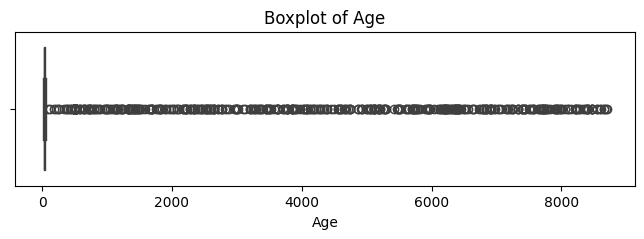

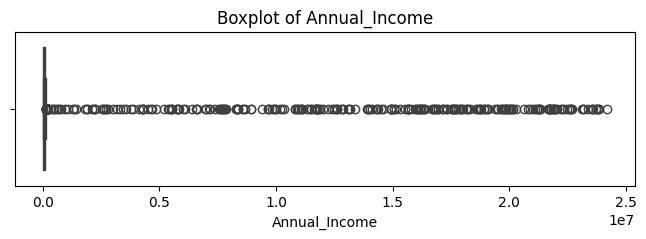

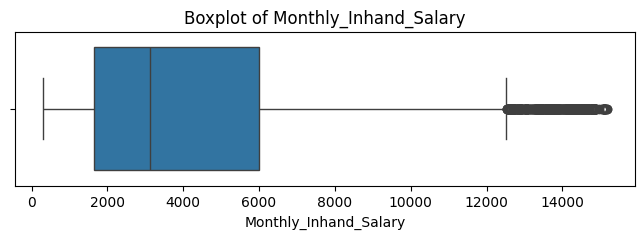

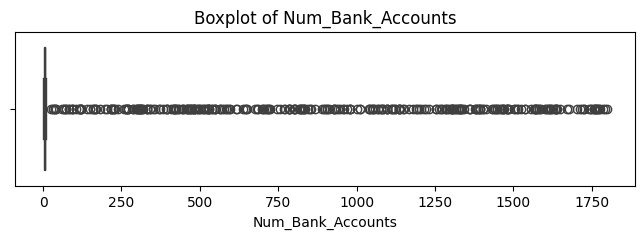

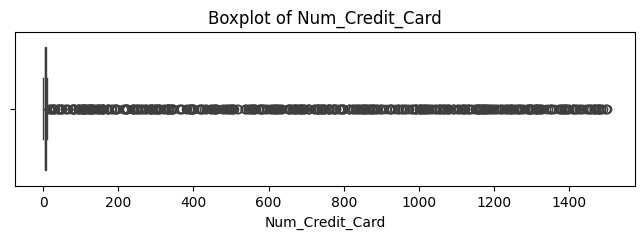

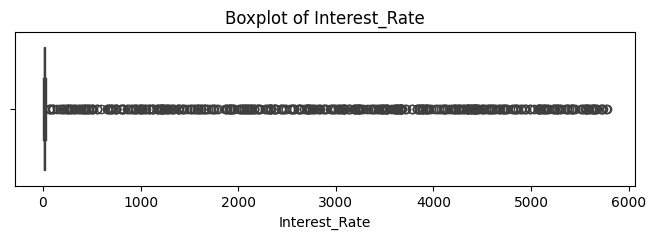

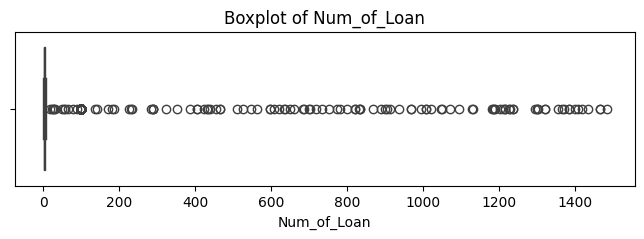

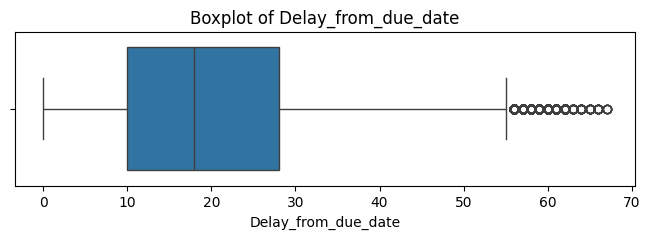

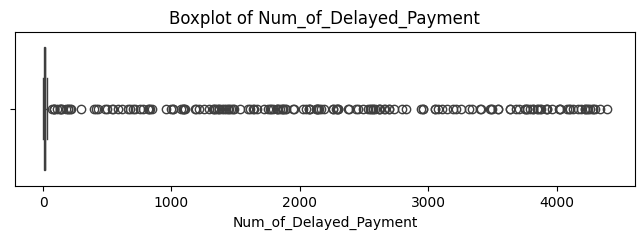

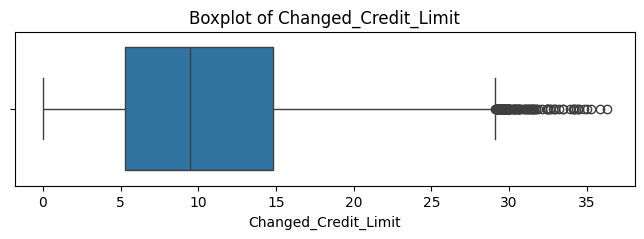

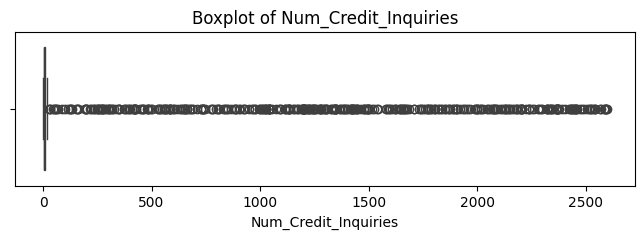

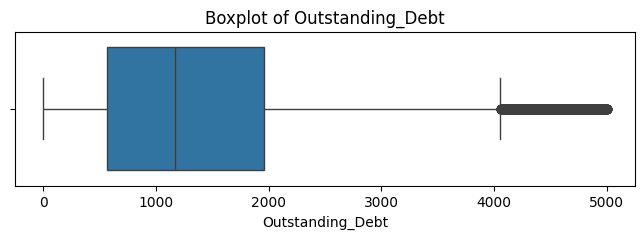

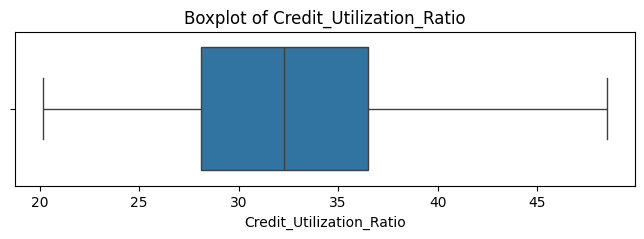

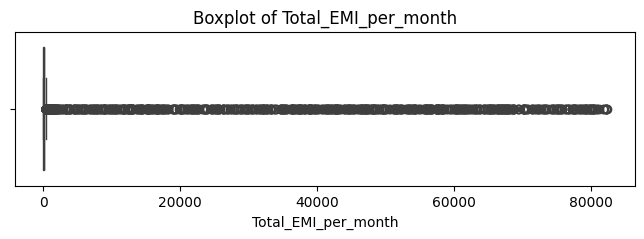

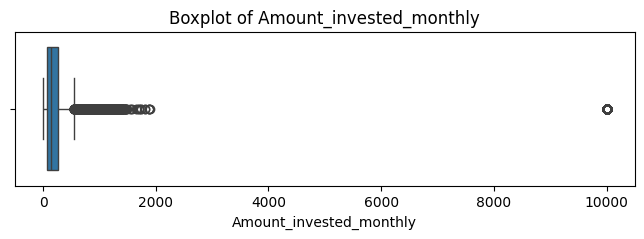

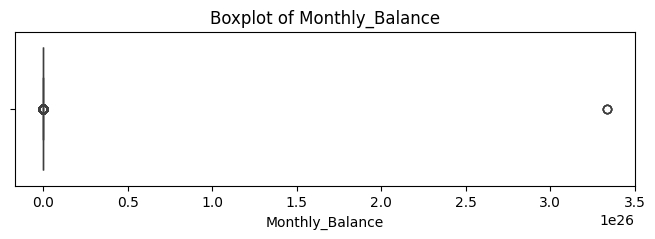

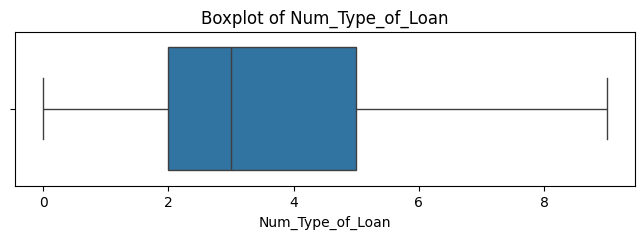

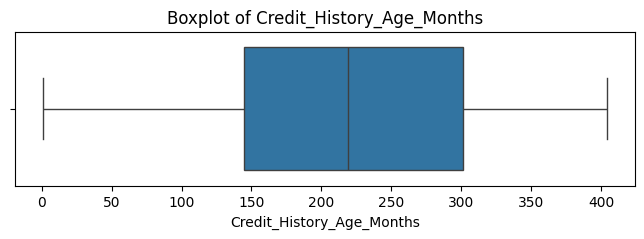

In [103]:
for col in numeric_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [104]:
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,1.142466e+02,6.618204e+02,14.000000,25.000000,33.000000,42.000000,8.698000e+03
Annual_Income,25000.0,1.918058e+05,1.531878e+06,7005.930000,19559.450000,37813.630000,73096.780000,2.418881e+07
Monthly_Inhand_Salary,21417.0,4.215671e+03,3.187623e+03,303.645417,1634.720833,3111.437500,5986.647500,1.516718e+04
Num_Bank_Accounts,25000.0,1.723576e+01,1.183074e+02,0.000000,4.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,25000.0,2.214308e+01,1.277018e+02,0.000000,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,25000.0,7.121404e+01,4.636691e+02,1.000000,8.000000,13.000000,20.000000,5.775000e+03
Num_of_Loan,25000.0,1.067924e+01,6.091063e+01,0.000000,2.000000,3.000000,6.000000,1.482000e+03
Delay_from_due_date,25000.0,2.122176e+01,1.484480e+01,0.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,23267.0,3.042021e+01,2.226142e+02,0.000000,9.000000,14.000000,18.000000,4.388000e+03
Changed_Credit_Limit,24482.0,1.045436e+01,6.654462e+00,0.010000,5.310000,9.440000,14.827500,3.629000e+01


Hasil eksplorasi data menunjukkan adanya nilai ekstrem pada fitur `Age`, `Interest_Rate`, `Monthly_Balance`, serta beberapa count variables. Fitur Interest_Rate ditangani dengan percentile capping pada P99 untuk membatasi ~1% nilai ekstrem tanpa mengurangi variasi data yang masih valid, sedangkan Monthly_Balance difilter dengan menghapus nilai > 1e6 karena berdasarkan analisis persentil (hingga P99.9 ≈ 1401.90) nilai tersebut dianggap tidak realistis.

Untuk `Age dan count variables`, digunakan metode IQR clipping (Q1 − 1.5 × IQR hingga Q3 + 1.5 × IQR), dengan batas dihitung dari data training dan diterapkan ke data testing untuk menghindari data leakage. 

Seluruh proses dilakukan setelah train-test split agar evaluasi tetap valid, sementara fitur finansial lainnya dipertahankan tanpa capping dan akan ditangani menggunakan Robust Scaler pada tahap training.

#### Correlation Check

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

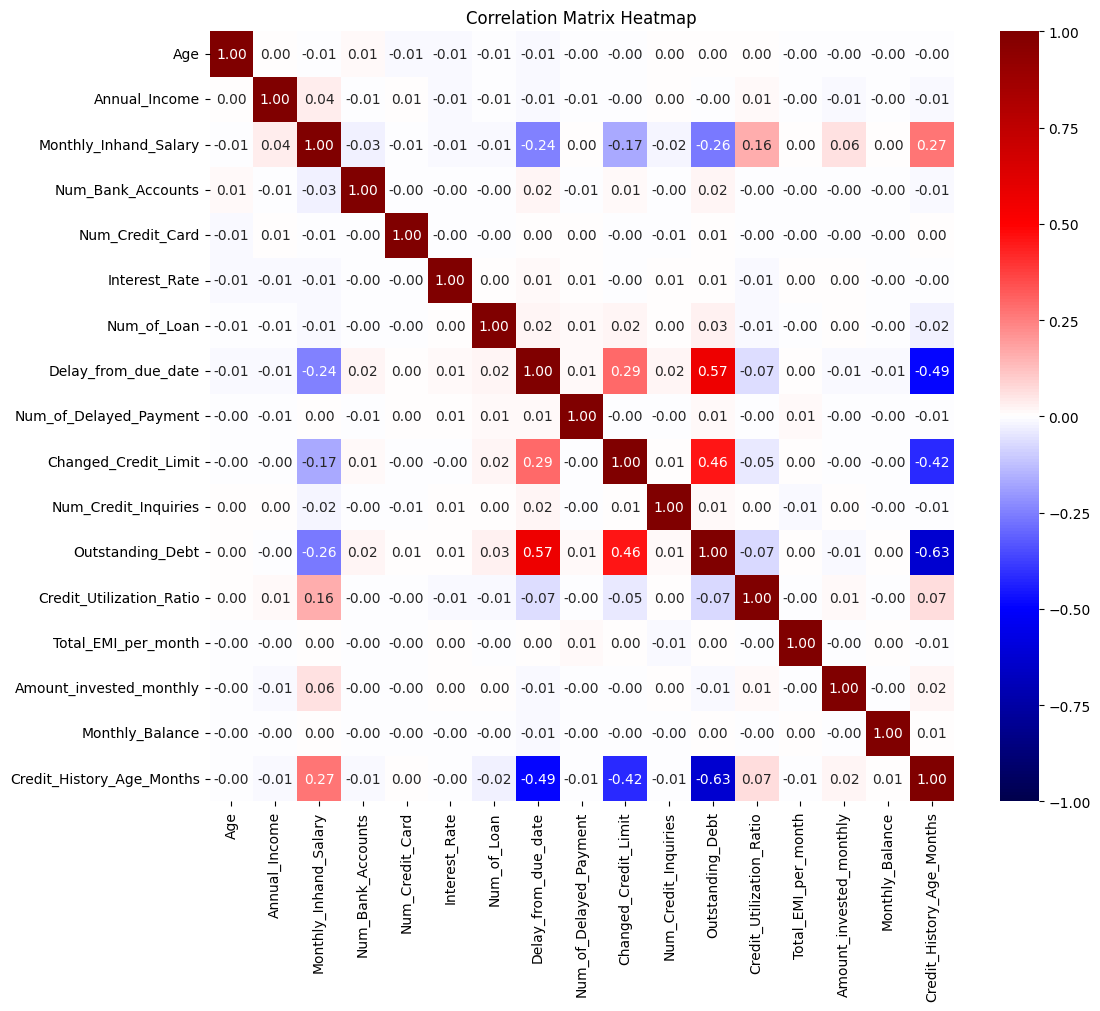

In [105]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Num_Type_of_Loan'], errors='ignore')

plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr,
            annot=True,
            cmap='seismic',
            fmt=".2f",
            vmin=-1,
            vmax=1)
plt.title('Correlation Matrix Heatmap')

Berdasarkan analisis Correlation Heatmap, terlihat beberapa hubungan yang cukup signifikan antar fitur. Variabel `Outstanding_Debt` memiliki korelasi positif dengan `Delay_from_due_date` (0,57) dan `Changed_Credit_Limit` (0,45), yang mengindikasikan bahwa nasabah dengan tingkat utang yang lebih tinggi cenderung memiliki keterlambatan pembayaran yang lebih besar serta mengalami perubahan limit kredit yang lebih signifikan. 

Di sisi lain, `Credit_History_Age_Months` menunjukkan korelasi negatif terhadap `Outstanding_Debt` (-0,60), `Delay_from_due_date` (-0,47), dan `Changed_Credit_Limit` (-0,40), yang menunjukkan bahwa nasabah dengan riwayat kredit yang lebih panjang cenderung memiliki kondisi kredit yang lebih baik dan risiko pembayaran yang lebih rendah.

Selain itu, `Monthly_Inhand_Salary` memiliki korelasi negatif terhadap `Outstanding_Debt` (-0,24) dan `Delay_from_due_date` (-0,22), yang mengindikasikan bahwa pendapatan bulanan yang lebih tinggi umumnya berkaitan dengan kemampuan pembayaran yang lebih baik. 

Namun, ditemukan anomali krusial berupa korelasi yang mendekati nol antara `Annual_Income` dan `Monthly_Inhand_Salary`, yang secara tidak masuk akal logika karena seharusnya berhubungan erat

In [106]:
print(df[['Annual_Income', 'Monthly_Inhand_Salary']].corr())

                       Annual_Income  Monthly_Inhand_Salary
Annual_Income               1.000000               0.035951
Monthly_Inhand_Salary       0.035951               1.000000


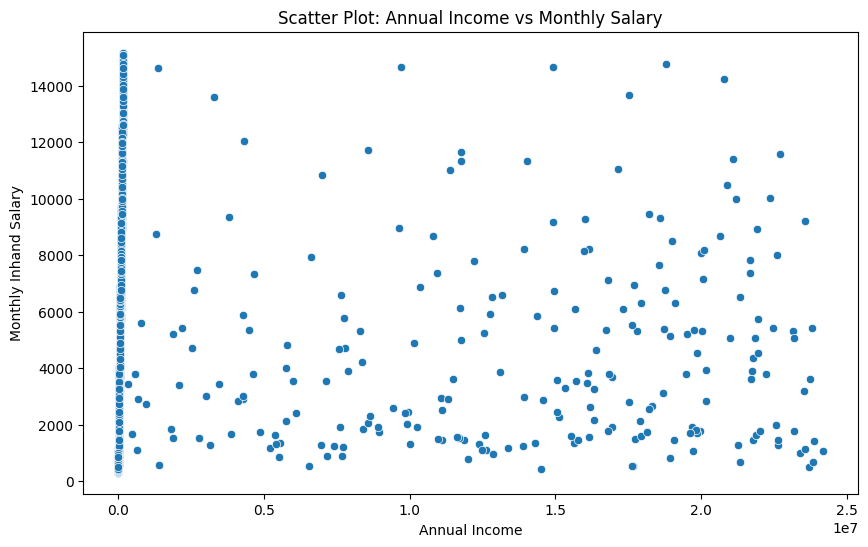

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Annual_Income'], y=df['Monthly_Inhand_Salary'])
plt.title('Scatter Plot: Annual Income vs Monthly Salary')
plt.xlabel('Annual Income')
plt.ylabel('Monthly Inhand Salary')
plt.show()

Scatter plot menunjukkan inkonsistensi skala ekstrem pada **Annual_Income**, dengan nilai yang mencapai **jutaan** sehingga tidak berkorelasi positif dengan **Monthly_Inhand_Salary**, mengindikasikan adanya potensi outlier akibat kesalahan input atau satuan. Untuk mencegah *data leakage*, penanganan variabel ini akan dilakukan pada tahap preprocessing setelah *data splitting*.

# 2. Splitting Data


### Split Data

In [108]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

target_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
y = y.map(target_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


### Handling Outlier

#### Analisis `Annual_Income` 

In [109]:
print(df['Annual_Income'].describe())

count    2.500000e+04
mean     1.918058e+05
std      1.531878e+06
min      7.005930e+03
25%      1.955945e+04
50%      3.781363e+04
75%      7.309678e+04
max      2.418881e+07
Name: Annual_Income, dtype: float64


In [110]:
print(df['Annual_Income'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

0.50      37813.630
0.75      73096.780
0.90     113293.179
0.95     134928.360
0.99    1895719.480
Name: Annual_Income, dtype: float64


In [111]:
Q1 = X_train['Annual_Income'].quantile(0.25)
Q3 = X_train['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
print(f"IQR upper bound: {upper}")

capped = X_train['Annual_Income'].clip(upper=upper)
print(capped.corr(X_train['Monthly_Inhand_Salary']))

IQR upper bound: 153118.745
0.9550253409072074


Berdasarkan hasil analisis, ditemukan nilai ekstrem pada `Annual_Income` yang meningkat pada persentil ke-99 (dari 135 ribu menjadi 1,9 juta), hal ini mengindikasikan adanya outlier akibat kesalahan input atau satuan pada sebagian kecil data.

Untuk memvalidasi hal ini, dilakukan pengujian *capping* menggunakan metode **IQR** pada `X_train`, dengan batas atas sebesar **153.118**, yang berhasil meningkatkan korelasi antara `Annual_Income` dan `Monthly_Inhand_Salary` dari mendekati **0,03** menjadi **0,95**.

Oleh karena itu, penanganan outlier pada variabel `Annual_Income` akan menggunakan **metode IQR**, karena terbukti efektif mengoreksi anomali data tanpa menghilangkan keseluruhan informasi pada variabel tersebut.

#### Handling `Monthly Balance`

In [112]:
X_train['Monthly_Balance'].quantile(
    [0.90, 0.95, 0.99, 0.999]
)

0.900     702.298745
0.950     859.914652
0.990    1127.378870
0.999    1404.065129
Name: Monthly_Balance, dtype: float64

In [113]:
corrupt_mask_train = X_train['Monthly_Balance'] > 1e6
print(f"Baris corrupt di X_train (Monthly_Balance > 1e6): {corrupt_mask_train.sum()}")

X_train = X_train[~corrupt_mask_train]
y_train = y_train[~corrupt_mask_train] 

Baris corrupt di X_train (Monthly_Balance > 1e6): 2


#### Handling `Age`, `Annual Income` & `Count Variables`

In [114]:
cols = [
    'Age',
    'Num_Credit_Card',
    'Num_Bank_Accounts',
    'Num_of_Loan',
    'Num_Credit_Inquiries',
    'Num_of_Delayed_Payment',
    'Annual_Income'
]

for col in cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test[col] = X_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    
for col in cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: [{lower_bound:.2f}, {upper_bound:.2f}]")

Age: [0.00, 69.00]
Num_Credit_Card: [0.00, 11.50]
Num_Bank_Accounts: [0.00, 13.00]
Num_of_Loan: [0.00, 12.00]
Num_Credit_Inquiries: [0.00, 18.00]
Num_of_Delayed_Payment: [0.00, 31.50]
Annual_Income: [0.00, 153059.59]


#### Handling `Interest_Rate`

In [115]:
df['Interest_Rate'].describe()

count    25000.000000
mean        71.214040
std        463.669065
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5775.000000
Name: Interest_Rate, dtype: float64

`Interest_Rate` ditangani menggunakan percentile capping pada persentil ke-99 (P99) karena metode ini hanya membatasi sekitar 1% nilai paling ekstrem sehingga dapat mengurangi pengaruh outlier tanpa menghilangkan variasi data yang masih berpotensi valid.

In [116]:
col = 'Interest_Rate'
upper_bound = X_train[col].quantile(0.99)

X_train[col] = X_train[col].clip(upper=upper_bound)
X_test[col] = X_test[col].clip(upper=upper_bound)

### Handling Missing Value

In [117]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

8001
2040


In [118]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include='object').columns

train_medians = X_train[numeric_cols].median()
train_modes = X_train[categorical_cols].mode().iloc[0]

X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_train[categorical_cols] = X_train[categorical_cols].fillna(train_modes)

X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)
X_test[categorical_cols] = X_test[categorical_cols].fillna(train_modes)

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


### Kesimpulan EDA

In [119]:
X_train.head(5)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Num_Type_of_Loan,Credit_History_Age_Months
3651,29.0,141897.840,11987.82000,4,7.0,6.0,12.0,16,14.0,16.09,...,Standard,1348.77,28.083772,Yes,647.160265,262.182819,High_spent_Large_value_payments,529.438916,7,87.0
11258,28.0,58539.840,4794.32000,6,7.0,32.0,8.0,17,18.0,9.47,...,Bad,2735.13,27.223961,Yes,236.562328,136.495534,High_spent_Medium_value_payments,382.808652,8,69.0
7593,37.0,139291.920,3106.84750,0,7.0,7.0,3.0,14,1.0,5.47,...,Good,281.26,27.429571,No,230.469810,517.189296,Unknown,688.406895,3,215.0
24538,27.0,124885.110,10127.09250,3,6.0,1.0,1.0,11,15.0,10.41,...,Good,935.74,33.169090,No,73.823162,859.859767,Low_spent_Medium_value_payments,359.026321,0,370.0
13332,22.0,18254.505,1605.20875,3,6.0,9.0,0.0,13,9.0,7.86,...,Standard,211.41,27.388045,No,0.000000,83.084252,Low_spent_Medium_value_payments,357.436623,0,229.0


In [120]:
X_test.head(5)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Num_Type_of_Loan,Credit_History_Age_Months
23093,36.0,73376.94,5961.745000,5,5.0,10.0,3.0,5,0.0,14.51,...,Good,493.15,23.680504,No,178.470965,509.022003,Low_spent_Large_value_payments,178.681532,3,271.0
5208,69.0,28501.86,2395.155000,4,2.0,10.0,2.0,5,14.0,10.78,...,Unknown,1045.30,26.485875,Unknown,29.153765,70.749079,Low_spent_Medium_value_payments,419.612656,2,289.0
2887,69.0,42921.75,3304.807427,2,4.0,4.0,4.0,19,12.0,8.87,...,Good,214.11,32.678094,No,203.550938,136.495534,Unknown,195.905434,4,214.0
4980,54.0,43924.04,3811.336667,1,7.0,6.0,2.0,5,5.0,0.60,...,Good,780.26,28.060921,No,63.313421,111.357353,High_spent_Medium_value_payments,456.462893,2,238.0
18919,18.0,18507.00,1561.250000,6,3.0,14.0,4.0,30,15.0,8.07,...,Standard,1814.83,33.192739,Yes,34.039146,50.109781,Low_spent_Medium_value_payments,351.976073,4,121.0


In [121]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19998 entries, 3651 to 3352
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        19998 non-null  float64
 1   Annual_Income              19998 non-null  float64
 2   Monthly_Inhand_Salary      19998 non-null  float64
 3   Num_Bank_Accounts          19998 non-null  int64  
 4   Num_Credit_Card            19998 non-null  float64
 5   Interest_Rate              19998 non-null  float64
 6   Num_of_Loan                19998 non-null  float64
 7   Delay_from_due_date        19998 non-null  int64  
 8   Num_of_Delayed_Payment     19998 non-null  float64
 9   Changed_Credit_Limit       19998 non-null  float64
 10  Num_Credit_Inquiries       19998 non-null  float64
 11  Credit_Mix                 19998 non-null  object 
 12  Outstanding_Debt           19998 non-null  float64
 13  Credit_Utilization_Ratio   19998 non-null  float6

In [122]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 23093 to 23979
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        5000 non-null   float64
 1   Annual_Income              5000 non-null   float64
 2   Monthly_Inhand_Salary      5000 non-null   float64
 3   Num_Bank_Accounts          5000 non-null   int64  
 4   Num_Credit_Card            5000 non-null   float64
 5   Interest_Rate              5000 non-null   float64
 6   Num_of_Loan                5000 non-null   float64
 7   Delay_from_due_date        5000 non-null   int64  
 8   Num_of_Delayed_Payment     5000 non-null   float64
 9   Changed_Credit_Limit       5000 non-null   float64
 10  Num_Credit_Inquiries       5000 non-null   float64
 11  Credit_Mix                 5000 non-null   object 
 12  Outstanding_Debt           5000 non-null   float64
 13  Credit_Utilization_Ratio   5000 non-null   float

In [138]:
pd.set_option('display.max_columns', None)
df_clean = pd.concat([X_train, y_train], axis=1)
df_clean.groupby("Credit_Score", group_keys=False).head(1).sort_values("Credit_Score")

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Num_Type_of_Loan,Credit_History_Age_Months,Credit_Score
7521,52.0,11855.82,943.985000,6,6.0,17.0,1.0,13,10.0,7.89,5.0,Standard,735.37,33.252435,Yes,5.711417,80.054233,Low_spent_Small_value_payments,298.632850,0,214.0,0
3651,29.0,141897.84,11987.820000,4,7.0,6.0,12.0,16,14.0,16.09,10.0,Standard,1348.77,28.083772,Yes,647.160265,262.182819,High_spent_Large_value_payments,529.438916,7,87.0,1
13712,19.0,39977.21,3583.434167,4,7.0,11.0,0.0,8,10.0,6.62,4.0,Unknown,832.09,28.812504,No,0.000000,348.016915,Low_spent_Small_value_payments,300.326502,0,366.0,2


- Dataset ini berisi 24998 Row dan 21 Kolom
- Jumlah ini berkurang dari total awal 25.000 baris karena dilakukan penghapusan (drop) terhadap 2 baris data yang dianggap corrupt atau extreme outlier pada kolom **Monthly_Balance** (memiliki nilai tidak masuk akal, yaitu > 1.000.000).
- Kolom Identifier yang tidak berguna untuk prediksi akan dilakukan proses drop seperti **Unnamed: 0, ID, Customer_ID, SSN, Name, Month, Occupation**
- Terdapat beberapa kolom yang seharusnya bertipe numerik tetapi masih bertipe object, sehingga dilakukan proses transformasi tipe data dari Object Menjadi float
- Pada variable kategorikal, terdapat beberapa value yang tidak informatif sehingga saya merubahnya menjadi "Unknown"
-  Pada kolom **Credit_History_Age** yang awalnya berupa String yang berisi Tahun dan bulan, saya transformasi semuanya menjadi numerik **Credit_History_Age_Months** dalam satuan bulan.
- Pada Variable **Type Of Loan**, karena jumlah unique yang besar dan duplikat, saya melakukan transformasi dengan membuat fitur numerik baru **Num_Type_of_Loan** untuk merepresentasikan jumlah jenis pinjaman.
Seluruh fitur kategorik memiliki proporsi yang seimbang
- Beberapa fitur yang memiliki Missing value, saya melakukann impute 
modus untuk variable kategorikal dan impute median untuk variable numerik
- Setelah pengecekan, tidak ditemukan duplicate row pada dataset ini
- Ditemukan value minus pada beberapa kolom numerik, sehingga saya gunakan absolute agar menjadi positif
- Ditemukan outlier pada beberapa fitur (**Age, Interest_Rate, Monthly_Balance, dan count variables**)
- **Interest_Rate** ditangani dengan P99 capping, **Monthly_Balance** difilter > 1e6, dan **Age** serta **count variables** menggunakan IQR clipping berbasis data training untuk mencegah data leakage, sementara fitur lain distabilkan dengan RobustScaler dalam pipeline.
- Korelasi awal menunjukkan anomali pada **Annual_Income** vs **Monthly_Inhand_Salary** yang disebabkan outlier ekstrem, sehingga **Annual_Income** tetap dipertahankan dan akan ditangani dengan IQR berbasis train set setelah splitting.

# 3. ColumnTransformer for Encoding & Scaling

In [124]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

ordinal_cols = ['Credit_Mix', 'Payment_of_Min_Amount']
ordinal_order = [
    ['Unknown', 'Bad', 'Standard', 'Good'],
    ['Unknown', 'No', 'Yes']
]

nominal_cols = ['Payment_Behaviour']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
	('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('nom', nominal_transformer, nominal_cols)
    ]
)

In [125]:
numeric_cols

['Age',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Num_Type_of_Loan',
 'Credit_History_Age_Months']

# 4. Train Model

In [126]:
preprocessor

,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Modelling Decision Tree

In [127]:
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(
        random_state=42,
		class_weight= 'balanced'
    ))
])

param_dt = {
    'clf__max_depth': [3, 5, 10, 15, 20, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    'clf__criterion': ['gini', 'entropy']
}

rs_dt = RandomizedSearchCV(
    estimator=pipe_dt,
    param_distributions=param_dt,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rs_dt.fit(X_train, y_train)

y_pred_dt = rs_dt.predict(X_test)
y_proba_dt = rs_dt.predict_proba(X_test)

### Modelling XGBoost

In [128]:
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
		class_weight= 'balanced'
    ))
])

param_xgb = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 6, 9],
    'clf__learning_rate': [0.05, 0.1, 0.2]
}

rs_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_xgb,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

y_pred_xgb = rs_xgb.predict(X_test)
y_proba_xgb = rs_xgb.predict_proba(X_test)

### Modelling Random Forest

In [129]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
		class_weight= 'balanced'
    ))
])

param_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, 30,None],
    'clf__min_samples_split': [2, 5, 10]
}

rs_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_rf,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

rs_rf.fit(X_train, y_train)

y_pred_rf = rs_rf.predict(X_test)
y_proba_rf = rs_rf.predict_proba(X_test)


### Modelling LightGBM

In [130]:
pipe_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1,
		class_weight= 'balanced'

    ))
])

param_lgbm = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 6, 9, -1],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__num_leaves': [31, 50, 100]
}

rs_lgbm = RandomizedSearchCV(
    estimator=pipe_lgbm,
    param_distributions=param_lgbm,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rs_lgbm.fit(X_train, y_train)

y_pred_lgbm = rs_lgbm.predict(X_test)
y_proba_lgbm = rs_lgbm.predict_proba(X_test)

# 5. Evaluation Model

### Decision Tree

Confusion Matrix DECISION TREE


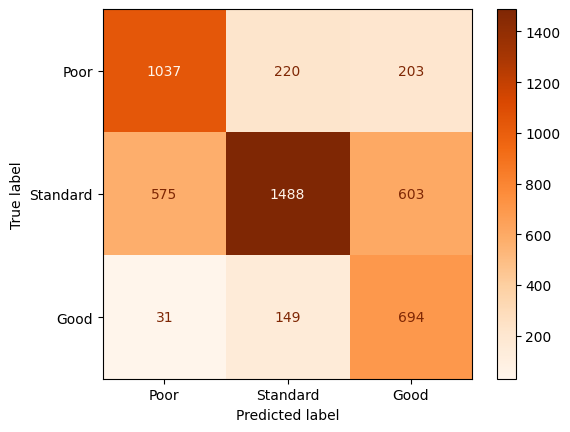


Classification Report DECISION TREE
              precision    recall  f1-score   support

        Poor       0.63      0.71      0.67      1460
    Standard       0.80      0.56      0.66      2666
        Good       0.46      0.79      0.58       874

    accuracy                           0.64      5000
   macro avg       0.63      0.69      0.64      5000
weighted avg       0.69      0.64      0.65      5000



In [131]:
print("Confusion Matrix DECISION TREE")

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Poor', 'Standard', 'Good']
)

disp.plot(cmap='Oranges')
plt.show()

print("\nClassification Report DECISION TREE")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Poor', 'Standard', 'Good']
    )
)

### Random Forest

Confusion Matrix Random Forest


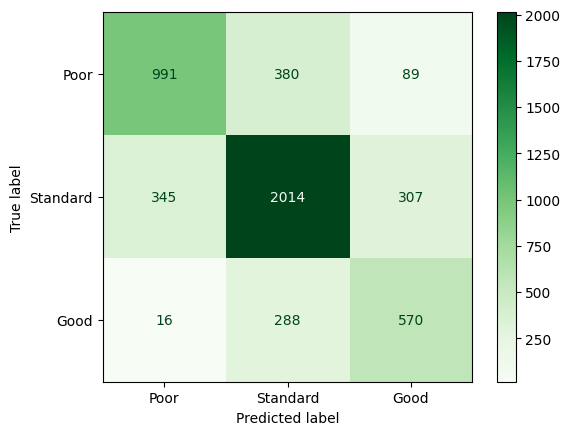


Classification Report Random Forest
              precision    recall  f1-score   support

        Poor       0.73      0.68      0.70      1460
    Standard       0.75      0.76      0.75      2666
        Good       0.59      0.65      0.62       874

    accuracy                           0.71      5000
   macro avg       0.69      0.70      0.69      5000
weighted avg       0.72      0.71      0.72      5000



In [132]:
print("Confusion Matrix Random Forest")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Standard', 'Good'])
disp.plot(cmap='Greens')
plt.show()
print("\nClassification Report Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['Poor', 'Standard', 'Good']))

### XGBOOST

Confusion Matrix XGBOOST


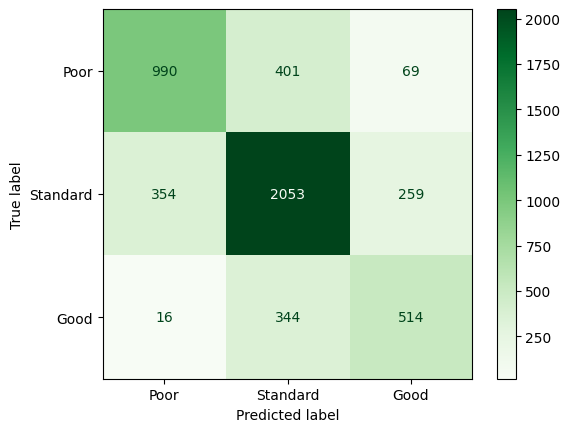


Classification Report XGBOOST
              precision    recall  f1-score   support

        Poor       0.73      0.68      0.70      1460
    Standard       0.73      0.77      0.75      2666
        Good       0.61      0.59      0.60       874

    accuracy                           0.71      5000
   macro avg       0.69      0.68      0.68      5000
weighted avg       0.71      0.71      0.71      5000



In [133]:
print("Confusion Matrix XGBOOST")
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Standard', 'Good'])
disp.plot(cmap='Greens')
plt.show()

print("\nClassification Report XGBOOST")
print(classification_report(y_test, y_pred_xgb, target_names=['Poor', 'Standard', 'Good']))

### LightGBM

Confusion Matrix LIGHTGBM


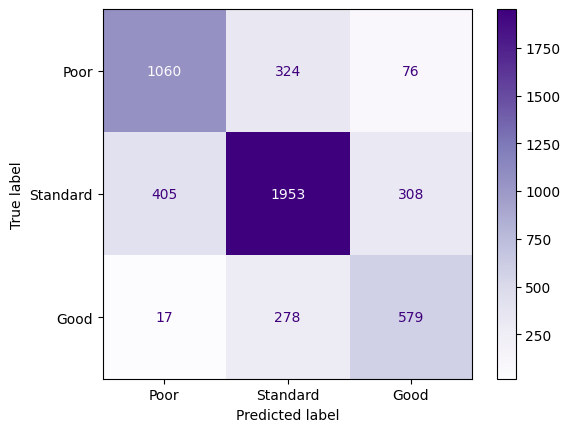


Classification Report LIGHTGBM
              precision    recall  f1-score   support

        Poor       0.72      0.73      0.72      1460
    Standard       0.76      0.73      0.75      2666
        Good       0.60      0.66      0.63       874

    accuracy                           0.72      5000
   macro avg       0.69      0.71      0.70      5000
weighted avg       0.72      0.72      0.72      5000



In [134]:
print("Confusion Matrix LIGHTGBM")

cm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Poor', 'Standard', 'Good']
)

disp.plot(cmap='Purples')
plt.show()

print("\nClassification Report LIGHTGBM")

print(
    classification_report(
        y_test,
        y_pred_lgbm,
        target_names=['Poor', 'Standard', 'Good']
    )
)

## Kesimpulan Model

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'LightGBM',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_lgbm, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ],
    'Best Parameters': [
        rs_dt.best_params_,
        rs_rf.best_params_,
        rs_lgbm.best_params_,
        rs_xgb.best_params_
    ]
})

results = results.sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

display(results)

best_model = results.iloc[0]

,Model,Accuracy,Macro F1,Best Parameters
0,LightGBM,0.7184,0.699702,"{'clf__num_leaves': 100, 'clf__n_estimators': ..."
1,Random Forest,0.7150,0.692527,"{'clf__n_estimators': 300, 'clf__min_samples_s..."
2,XGBoost,0.7114,0.684220,"{'clf__n_estimators': 300, 'clf__max_depth': 9..."
3,Decision Tree,0.6438,0.637008,"{'clf__min_samples_split': 5, 'clf__min_sample..."


In [136]:
for model_name, params in [
    ('LightGBM', rs_lgbm.best_params_),
	('Random Forest', rs_rf.best_params_),
    ('XGBoost', rs_xgb.best_params_)
]:
    print(f'\n{model_name}')
    display(pd.DataFrame(params.items(), columns=['Parameter', 'Value']))


LightGBM


,Parameter,Value
0,clf__num_leaves,100.0
1,clf__n_estimators,200.0
2,clf__max_depth,9.0
3,clf__learning_rate,0.2



Random Forest


,Parameter,Value
0,clf__n_estimators,300
1,clf__min_samples_split,5
2,clf__max_depth,30



XGBoost


,Parameter,Value
0,clf__n_estimators,300.0
1,clf__max_depth,9.0
2,clf__learning_rate,0.2


Pemilihan model klasifikasi mempertimbangkan dua metrik, yaitu **Accuracy** dan **Macro F1-Score**. Accuracy digunakan untuk melihat performa model secara umum, sementara Macro F1-Score dijadikan metrik utama karena lebih representatif dalam mengukur kemampuan model mengklasifikasikan ketiga kelas `Credit_Score` (**Good**, **Standard**, **Poor**) secara seimbang, tanpa bias terhadap kelas yang jumlah datanya lebih dominan.

Hasil evaluasi menunjukkan **LightGBM** sebagai model dengan performa terbaik, mencatatkan Accuracy sebesar **71,84%** dan Macro F1-Score sebesar **69,97%**, diikuti oleh **Random Forest** dan **XGBoost** dengan hasil yang tidak jauh berbeda. Hal ini mengindikasikan bahwa model-model berbasis ensemble lebih mampu menangkap pola kompleks pada data credit scoring dibandingkan model pohon keputusan tunggal.

Meskipun **LightGBM** terpilih sebagai model dengan performa terbaik, proses deployment tetap dilakukan terhadap tiga model dengan hasil tertinggi, yaitu **LightGBM**, **Random Forest**, dan **XGBoost**. Pendekatan ini diambil untuk membandingkan performa ketiga model secara langsung pada lingkungan deployment, sekaligus memastikan model yang dipilih nantinya tetap konsisten dan andal dalam memprediksi data baru.